# 1 Dimensional Heat Equation

$$ \frac{\partial u}{\partial t} = \sigma \frac{\partial^2 u}{\partial x^2} $$

In this small analysis, we will assume periodic Dirichlet Boundary Conditions: 
$$ u(-1, t) = u(1, t) = 0 $$
with the following Initial Condition:
$$ u(x, 0) =  \sin(2 \pi x ) $$

In [21]:
import math
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.animation as ani # type: ignore
import functools
import matplotlib.animation as animation
from IPython.display import HTML

### Functional conditions

In [22]:
sigma = 1
r = .4
N = 201 # number of points in the mesh
dx = 2/(N -1)
dt = r * dx**2/sigma
M = 4000 # number of time steps
T = M * dt

X = np.linspace(-1,1, N)
U = np.zeros((N,M))

# Initial Condition

In [23]:
def U0(x):
    return(np.sin(2*np.pi*x))

# Implementation of the FTCS discretization

In [24]:
#Adding the initial condition values to the solution Matrix
U[:,0] = U0(X)

# Implementing the FTCS
for n in range(M-1):
    for j in range(0, N-1):
        U[j,n+1] = r*U[j+1, n] + (1-2*r)*U[j,n] + r*U[j-1, n]

# Plotting some specific instances

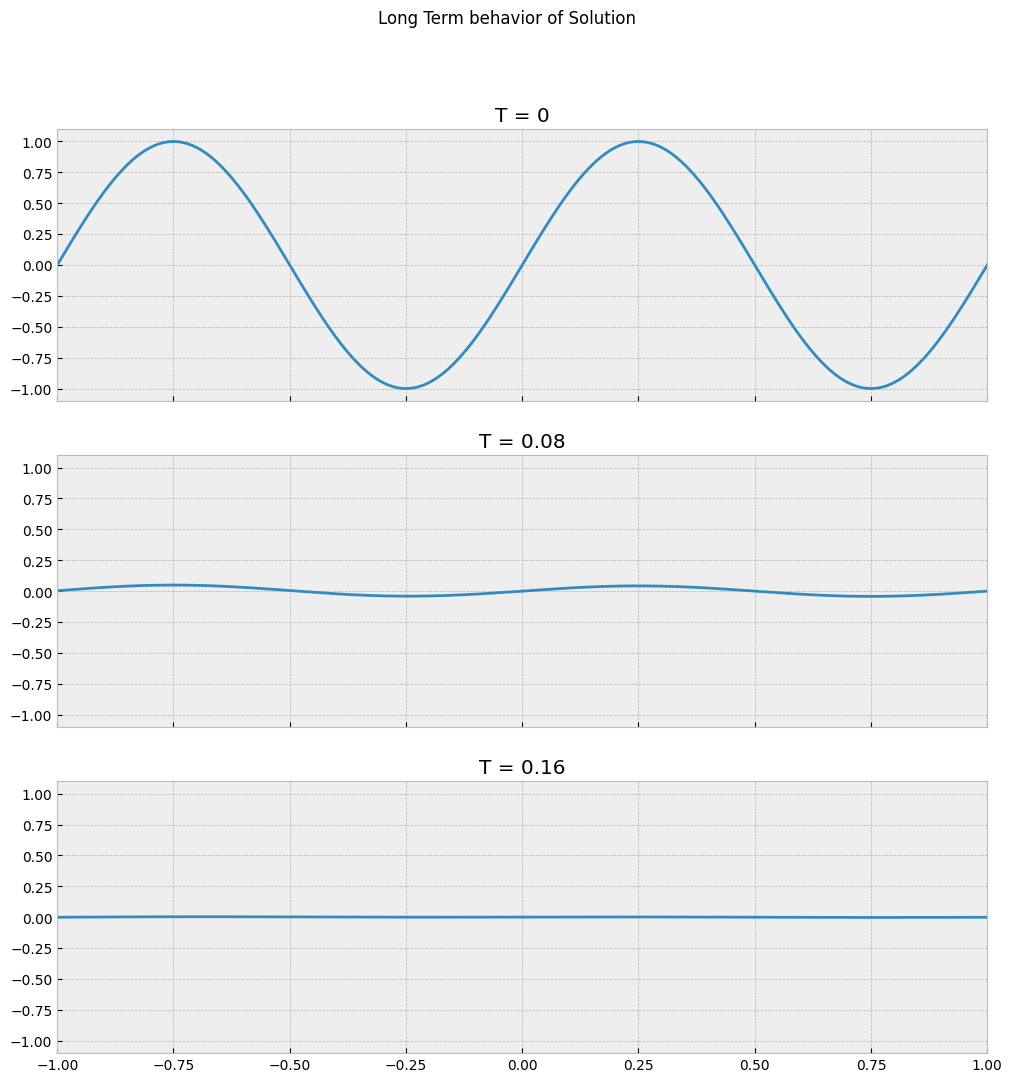

In [25]:
fig, ax = plt.subplots(3, sharex=True, sharey=True, figsize=(12, 12))
fig.suptitle("Long Term behavior of Solution")

ax[0].set_ylim([X.min()-.1, X.max()+.1])
ax[0].set_xlim([U.min(), U.max()])

ax[0].set_title("T = 0")
ax[1].set_title("T = " + str(round(T/2, 4)))
ax[2].set_title("T = " + str(round(T, 4)))


ax[0].plot(X, U[:,0])
ax[1].plot(X, U[:,int(M/2)])
ax[2].plot(X, U[:,M-1])

plt.style.use('bmh')
plt.show()

# Now let us observe the differences in the solution behaviour when altering $\sigma$ 

We now assume that $\Delta x = 10^{-2}$ is sufficiently small to have an accurate solution

In [26]:
# Initializing Conditions for the following three cases
r = .4
dx = (10**-2)/2
N = int(2/dx + 1)
T = .1

# Case 1: 
$ \sigma = 1/2, T \in [0,.1] $

In [27]:
# Variable Conditions:
sigma = .5
dt = r * dx**2/sigma
M = int(T/dt)

# Solution Setup
X = np.linspace(-1,1, N) # Space variables
U_1 = np.zeros((N,M)) # Solution Matix

#Adding the Initial Condition values to the solution Matrix
U_1[:,0] = U0(X) 

# Implementation of the FTCS
for n in range(0, M-1):
    for j in range(0, N-1):
        U_1[j,n+1] = r*U_1[j+1, n] + (1-2*r)*U_1[j,n] + r*U_1[j-1, n]

# Case 2: 
$ \sigma = 1, T \in [0,.1] $

In [28]:
# Variable Conditions:
sigma = 1
dt = r * dx**2/sigma
M = int(T/dt)


# Solution Setup
X = np.linspace(-1,1, N) # Space variables
U_2 = np.zeros((N,M)) # Solution Matix

#Adding the Initial Condition values to the solution Matrix
U_2[:,0] = U0(X) 


# Implementation of the FTCS
for n in range(0, M-1):
    for j in range(0, N-1):
        U_2[j,n+1] = r*U_2[j+1, n] + (1-2*r)*U_2[j,n] + r*U_2[j-1, n]

# Case 3: 
$ \sigma = 2, T \in [0,.1] $

In [29]:
# Variable Conditions:
sigma = 2
dt = r * dx**2/sigma
M = int(T/dt)


# Solution Setup
X = np.linspace(-1,1, N) # Space variables
U_3 = np.zeros((N,M)) # Solution Matix

#Adding the Initial Condition values to the solution Matrix
U_3[:,0] = U0(X) 

# Implementation of the FTCS
for n in range(0, M-1):
    for j in range(0, N-1):
        U_3[j,n+1] = r*U_3[j+1, n] + (1-2*r)*U_3[j,n] + r*U_3[j-1, n]

# Plotting

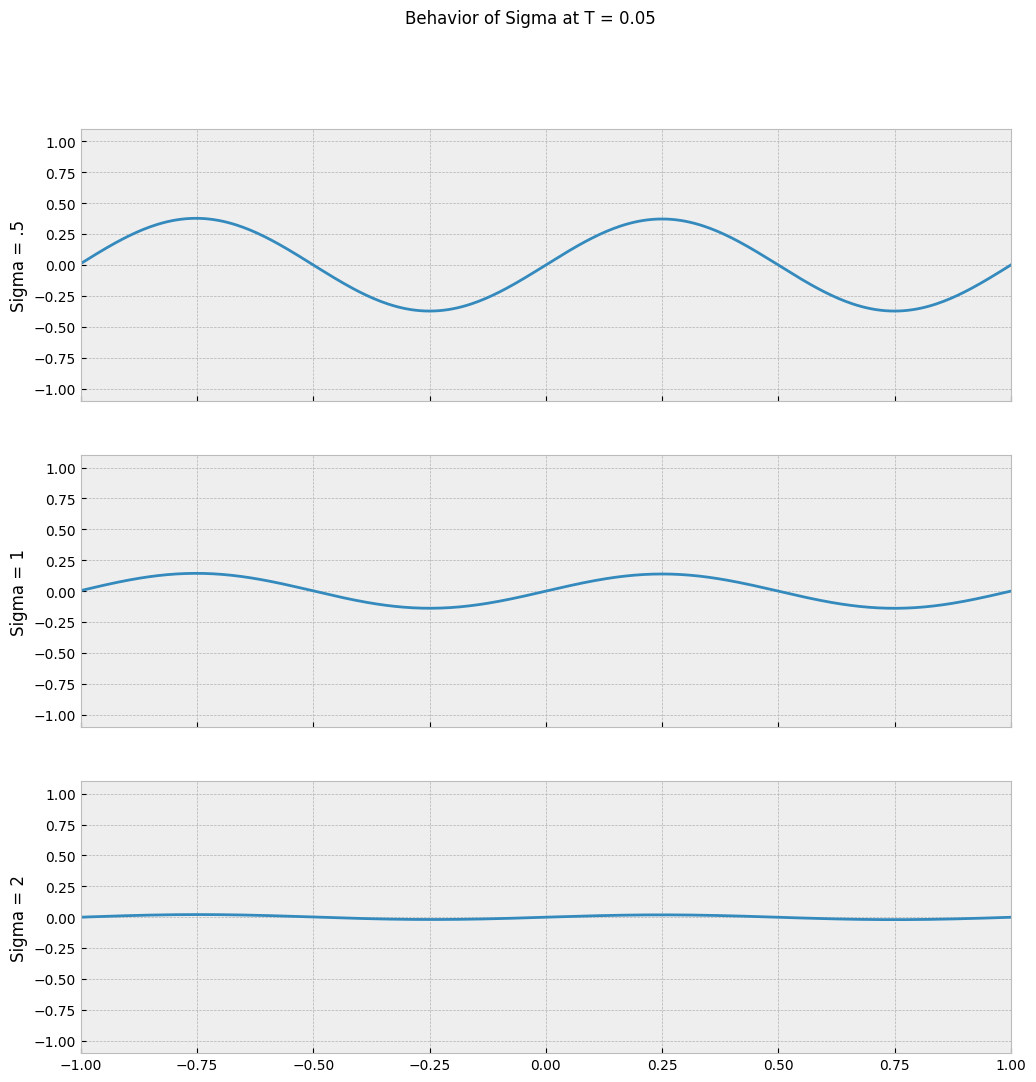

In [30]:
# Setting the desited time:
time = 1/2

# Plotting Code
fig, ax = plt.subplots(3, sharex=True, sharey=True, figsize=(12, 12))
fig.suptitle("Behavior of Sigma at T = " + str(T*time))

ax[0].set_ylim([X.min()-.1, X.max()+.1])
ax[0].set_xlim([U_1.min(), U_1.max()])

ax[0].set_ylabel("Sigma = .5")
ax[1].set_ylabel("Sigma = 1")
ax[2].set_ylabel("Sigma = 2")

ax[0].plot(X, U_1[:,int(U_1.shape[1]*time)])
ax[1].plot(X, U_2[:,int(U_2.shape[1]*time)])
ax[2].plot(X, U_3[:,int(U_3.shape[1]*time)])

plt.style.use('bmh')
plt.show()

We can clearly see that as sigma increases, the solution decays at a much faster rate. 

# Now let us add a source term! 

Let us begin by adding a single source term and view the behavour of the function

In [31]:
# Variable Conditions:
sigma = 1
r = .4
N = 201 # number of points in the mesh
dx = 2/(N -1)
dt = r * dx**2/sigma
M = 400 # number of time steps
T = M * dt

f = 5 # Source 

time = np.zeros(M+1)
for i in range(M+1):
  time[i] = i*dt
  
# Solution Setup
X = np.linspace(-1,1, N) # Space variables
U_s = np.zeros((N,M)) # Solution Matix

#Adding the Initial Condition values to the solution Matrix with the addition of the source term
f_0 = np.zeros(N)
f_0[int(N/2)] = f
U_s[:,0] = U0(X) + f_0


#Implementation of the FTCS
for n in range(0, M-1):
    for j in range(0, N-1):
        U_s[j,n+1] = r*U_s[j+1, n] + (1-2*r)*U_s[j,n] + r*U_s[j-1, n] + f_0[j]

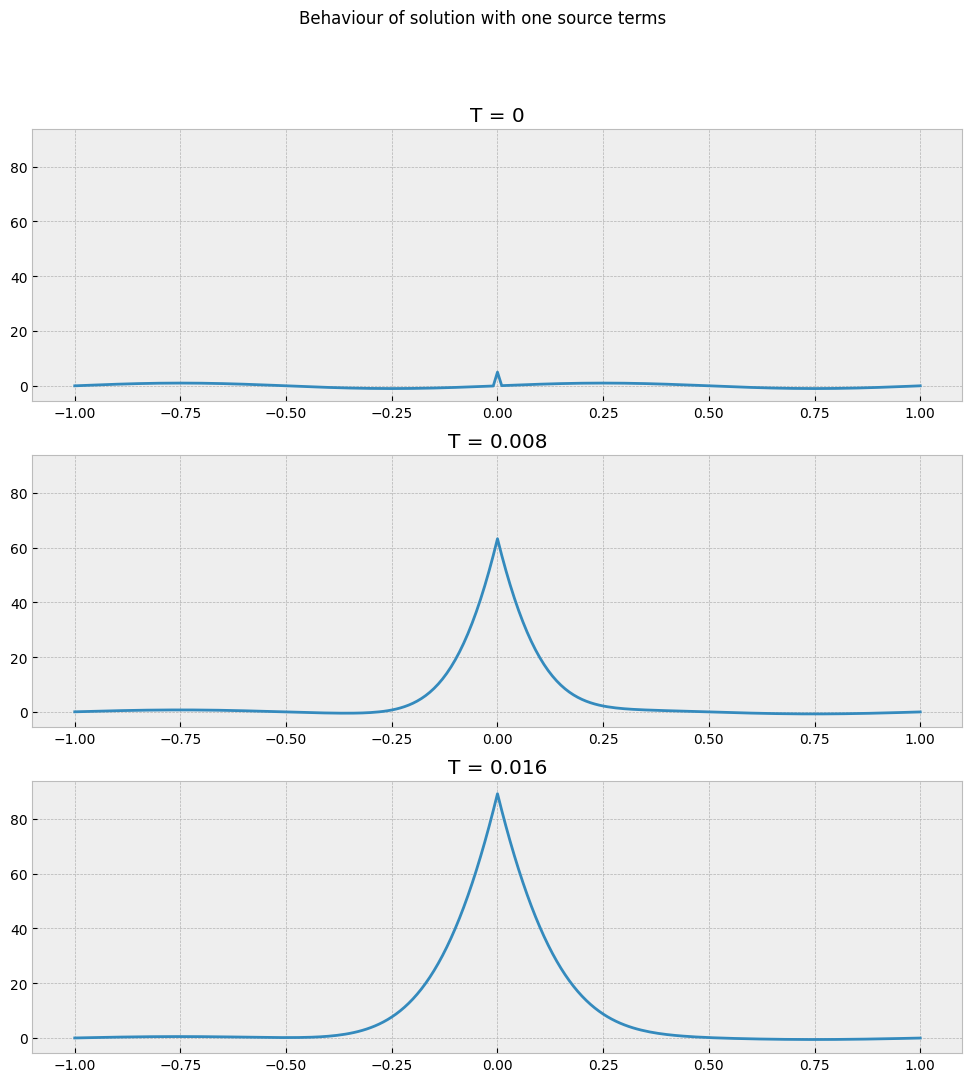

In [32]:
# Plotting instances in time
fig, ax = plt.subplots(3, figsize=(12, 12), sharey=True,)
fig.suptitle("Behaviour of solution with one source terms")

ax[0].set_title("T = 0")
ax[1].set_title("T = " + str(round(T/2, 4)))
ax[2].set_title("T = " + str(round(T, 4)))


ax[0].plot(X, U_s[:,0])
ax[1].plot(X, U_s[:,int(M/2)])
ax[2].plot(X, U_s[:,M-1])

plt.style.use('bmh')
plt.show()

### Now let us add two source terms

In [33]:
# Variable Conditions:
sigma = 1
r = .4
N = 201 # number of points in the mesh
dx = 2/(N -1)
dt = r * dx**2/sigma
M = 400 # number of time steps
T = M * dt

f = 5 # Source 

time = np.zeros(M+1)
for i in range(M+1):
  time[i] = i*dt
  
# Solution Setup
X = np.linspace(-1,1, N) # Space variables
U_s = np.zeros((N,M)) # Solution Matix

#Adding the Initial Condition values to the solution Matrix with the addition of the source term
f_0 = np.zeros(N)
f_0[int(N/4)] = f
f_0[int(3*N/4)] = f
U_s[:,0] = U0(X) + f_0


#Implementation of the FTCS
for n in range(0, M-1):
    for j in range(0, N-1):
        U_s[j,n+1] = r*U_s[j+1, n] + (1-2*r)*U_s[j,n] + r*U_s[j-1, n] + f_0[j]

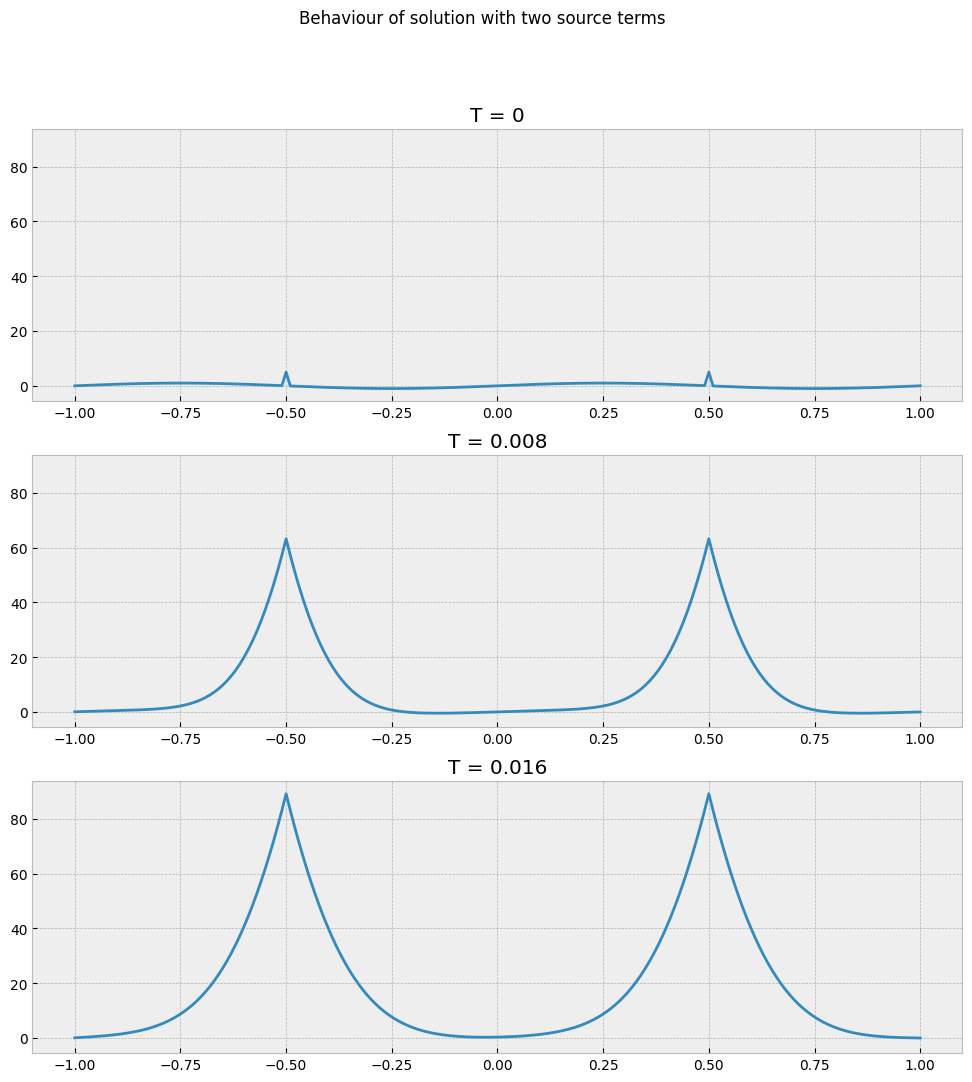

In [34]:
# Plotting instances in time
fig, ax = plt.subplots(3, figsize=(12, 12), sharey=True,)
fig.suptitle("Behaviour of solution with two source terms")

ax[0].set_title("T = 0")
ax[1].set_title("T = " + str(round(T/2, 4)))
ax[2].set_title("T = " + str(round(T, 4)))


ax[0].plot(X, U_s[:,0])
ax[1].plot(X, U_s[:,int(M/2)])
ax[2].plot(X, U_s[:,M-1])

plt.style.use('bmh')
plt.show()